# Exercise 08: Exogenous vs Endogenous Variables (VARX)

**CBIOMES Workshop · Time Series in R**

In this notebook you will:

1. Reason about which variables are **endogenous** (driven within the system) vs **exogenous** (external drivers).
2. Fit a **VARX**, a VAR with extra exogenous predictors using the `vars` package.
3. Diagnose residuals and read off **endogenous lag** structure plus **exogenous** effects.

## Setup

All packages already installed in the Docker container.

Expected files: `time_series_imp.csv`, `metadata_time_series_imp.csv` (the imputed datasets from Exercise 07).

In [1]:
#install.packages("reshape2")

In [2]:
library(vars)
library(reshape2)
library(ggplot2)

Loading required package: MASS

Loading required package: strucchange

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich

Loading required package: urca

Loading required package: lmtest



## Background: endogenous vs exogenous

In a VARX(p,s):

$$ \mathbf{y}_t = \sum_{l=1}^{p}\mathbf{A}_l\,\mathbf{y}_{t-l} + \sum_{j=0}^{s}\mathbf{B}_j\,\mathbf{x}_{t-j} + \boldsymbol\varepsilon_t $$

- $\mathbf{y}_t$ — **endogenous** vector: explained by its own past plus exogenous inputs.
- $\mathbf{x}_t$ — **exogenous** vector: drives $\mathbf{y}_t$ but is not explained by it.

---

## Exercise 1 — A conceptual quiz

Consider a coastal ecosystem with these variables:

- $z_1$ — phytoplankton biomass
- $z_2$ — zooplankton abundance
- $z_3$ — nutrient concentration (NO₃)
- $z_4$ — river discharge
- $z_5$ — sea surface temperature
- $z_6$ — fishing effort

**(a)** Classify each as endogenous or exogenous.

**(b)** Suppose nutrients influence policy decisions, and policy affects future fishing effort. Does this violate exogeneity for $z_6$?

**(c)** Suppose river discharge is influenced by rainfall, which is affected by evaporation driven by phytoplankton activity. Does the classification of $z_4$ change?

<details>
<summary><b>Suggested answers</b></summary>

**(a)** Phytoplankton, zooplankton, nutrients form a tightly coupled food web → **endogenous**. River discharge, sea surface temperature, fishing effort are typically external drivers → **exogenous**.

**(b)** Yes — if a state of the system ($z_3$) feeds back into $z_6$, then $z_6$ is no longer strictly exogenous; the system has become a coupled socio-ecological one and a VAR (without the "X") would be more honest, including $z_6$ as endogenous.

**(c)** Yes — once phytoplankton can affect rainfall (and thus $z_4$), $z_4$ has feedback from inside the system and is no longer strictly exogenous.

The lesson: "exogenous" depends on the **scope** of your model.
</details>

---

## Exercise 2: Fit a VARX with one exogenous variable

We use the **first three** columns of the imputed time series as the endogenous block, and **column Temperature** of the metadata as a single exogenous variable.

In [3]:
time_series <- as.data.frame(read.csv("time_series_imp.csv"))
metadata    <- as.data.frame(read.csv("metadata_time_series_imp.csv"))
colnames(metadata) <- c("Temperature", "oxy_ml_per_L", "Chl",
                        "pressure", "NO3_LOD2", "NO2_LOD2",
                        "Silicate_LOD2", "PO4_LOD2")
cat("Endogenous (first 3 cols of time series):\n")
print(head(time_series[, 1:3]))
cat("\nExogenous (Temperature from metadata):\n")
print(head(metadata$Temperature))

Endogenous (first 3 cols of time series):
         X1       X2       X3
1  9.245109 7.766839 8.861137
2  9.123113 7.780486 9.087965
3 10.190874 8.055112 8.808485
4 10.031230 7.579260 8.555214
5  9.844316 7.862459 8.550335
6 10.472133 8.135762 9.069090

Exogenous (Temperature from metadata):
[1] 14.53846 13.54635 12.90231 12.17780 11.11577 11.15858


In [4]:
endo <- as.matrix(time_series[, 1:3])
exo  <- as.matrix(metadata[, "Temperature", drop = FALSE])
colnames(exo) <- "Temperature"

fit_varx <- VAR(endo, p = 2, type = "const", exogen = exo)
summary(fit_varx)


VAR Estimation Results:
Endogenous variables: X1, X2, X3 
Deterministic variables: const 
Sample size: 142 
Log Likelihood: -414.397 
Roots of the characteristic polynomial:
 1.03 0.7633 0.298 0.2613 0.1272 0.04175
Call:
VAR(y = endo, p = 2, type = "const", exogen = exo)


Estimation results for equation X1: 
X1 = X1.l1 + X2.l1 + X3.l1 + X1.l2 + X2.l2 + X3.l2 + const + Temperature 

            Estimate Std. Error t value Pr(>|t|)    
X1.l1        0.84913    0.12699   6.687 5.63e-10 ***
X2.l1        0.09562    0.12764   0.749   0.4551    
X3.l1       -0.01247    0.07687  -0.162   0.8714    
X1.l2        0.12132    0.06455   1.880   0.0623 .  
X2.l2       -0.04644    0.07080  -0.656   0.5130    
X3.l2        0.03205    0.04484   0.715   0.4760    
const       -0.06119    0.04027  -1.519   0.1310    
Temperature -0.01510    0.01207  -1.251   0.2131    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Residual standard error: 0.7747 on 134 degrees of freedom
Multiple 

### Residual diagnostics


	Box-Ljung test

data:  res[, "X1"]
X-squared = 22.222, df = 10, p-value = 0.01401


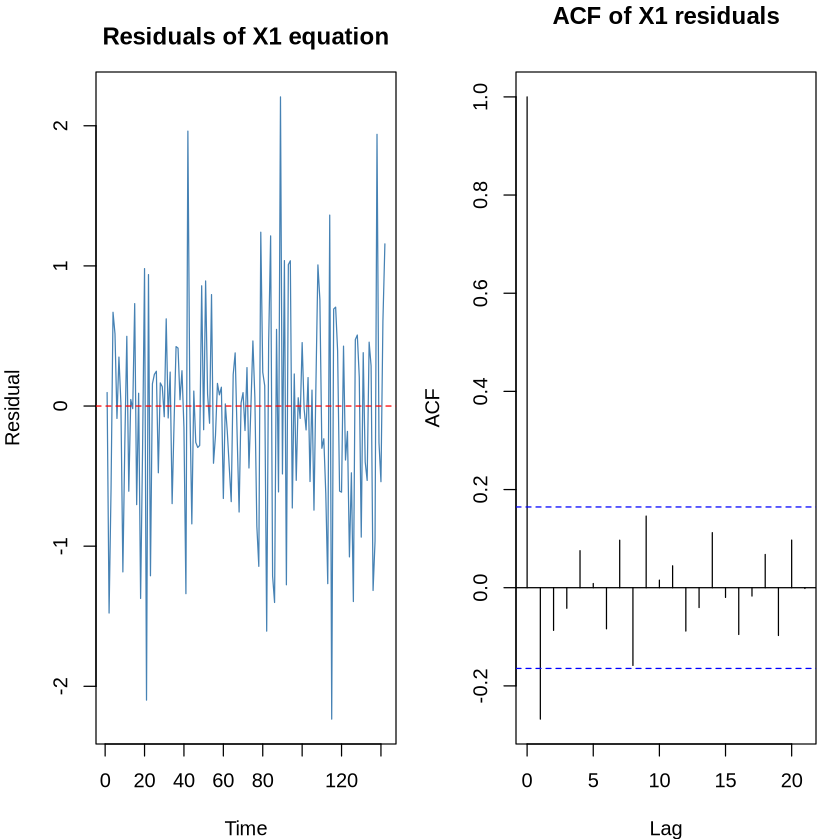

In [5]:
res <- residuals(fit_varx)

par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
plot(res[, "X1"], type = "l", col = "steelblue",
     main = "Residuals of X1 equation",
     xlab = "Time", ylab = "Residual")
abline(h = 0, col = "red", lty = 2)
acf(res[, "X1"], main = "ACF of X1 residuals")
par(mfrow = c(1, 1))

Box.test(res[, "X1"], lag = 10, type = "Ljung-Box")

### Fitted vs. observed

In [6]:
fitted_vals <- fitted(fit_varx)
n_fit <- nrow(fitted_vals)
actual_vals <- endo[(nrow(endo) - n_fit + 1):nrow(endo), ]

rmse_per_var <- sqrt(colMeans((actual_vals - fitted_vals)^2))
cat("RMSE per variable:\n")
print(round(rmse_per_var, 4))

RMSE per variable:
    X1     X2     X3 
0.7526 0.8447 0.8421 


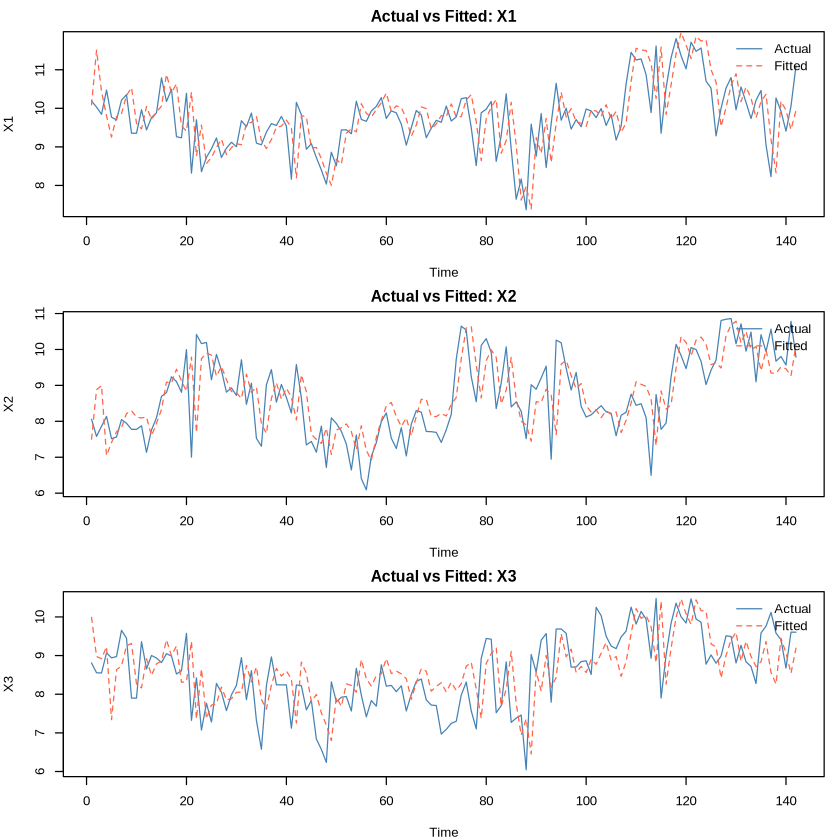

In [7]:
par(mfrow = c(ncol(fitted_vals), 1), mar = c(4, 4, 2, 1))
for (v in colnames(fitted_vals)) {
    plot(actual_vals[, v], type = "l", col = "steelblue",
         main = paste("Actual vs Fitted:", v),
         xlab = "Time", ylab = v)
    lines(fitted_vals[, v], col = "tomato", lty = 2)
    legend("topright", legend = c("Actual", "Fitted"),
           col = c("steelblue", "tomato"), lty = c(1, 2), bty = "n")
}
par(mfrow = c(1, 1))

### Endogenous lag structure (heatmaps)

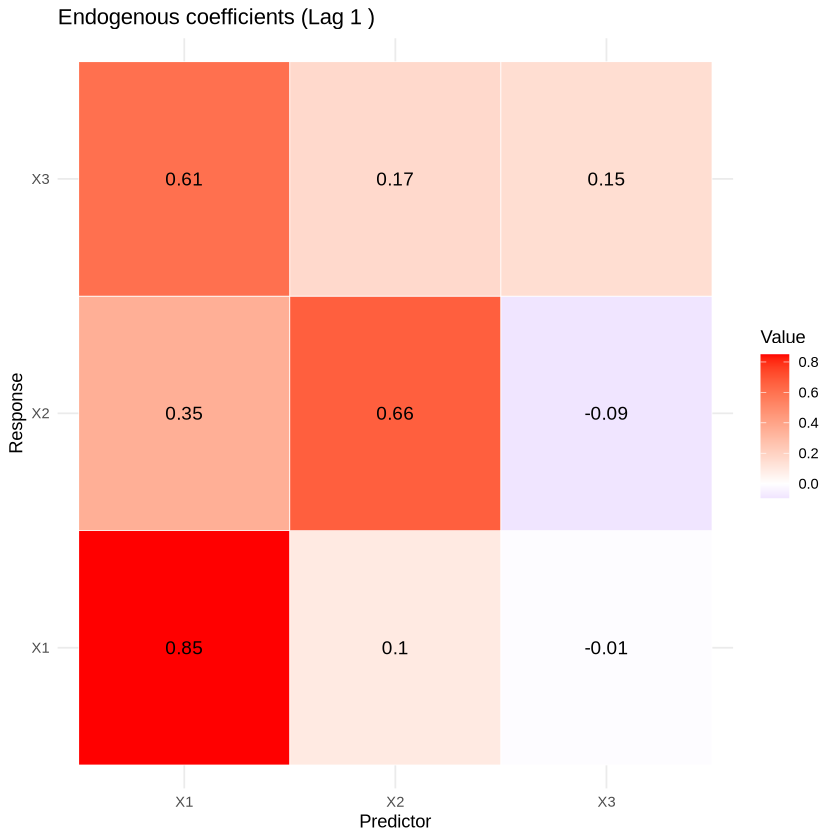

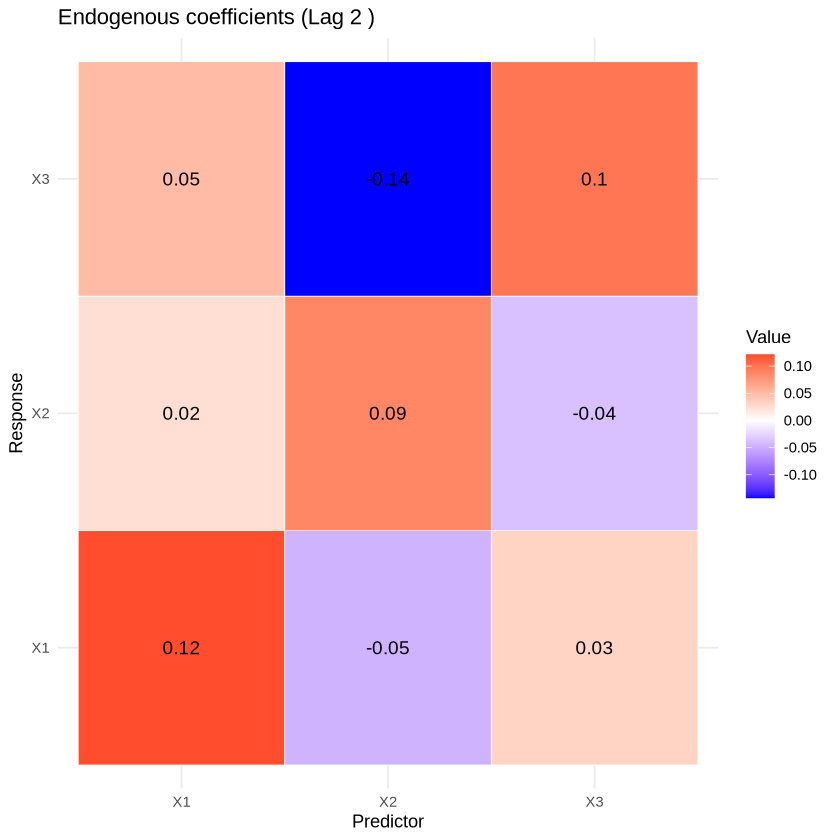

In [8]:
k         <- ncol(endo)
p         <- fit_varx$p
var_names <- colnames(endo)

A_list <- vector("list", p)
for (lag in seq_len(p)) {
    A_l <- matrix(0, nrow = k, ncol = k,
                  dimnames = list(var_names, var_names))
    for (eq_idx in seq_len(k)) {
        coef_eq <- coef(fit_varx)[[eq_idx]]
        for (pred_idx in seq_len(k)) {
            pat <- paste0("^", make.names(var_names[pred_idx]), "\\.l", lag, "$")
            m   <- grep(pat, rownames(coef_eq))
            if (length(m) > 0) {
                A_l[eq_idx, pred_idx] <- coef_eq[m, "Estimate"]
            }
        }
    }
    A_list[[lag]] <- A_l
}

for (lag in seq_len(p)) {
    df <- melt(A_list[[lag]])
    colnames(df) <- c("Response", "Predictor", "Value")
    print(
        ggplot(df, aes(x = Predictor, y = Response, fill = Value)) +
            geom_tile(color = "white") +
            geom_text(aes(label = round(Value, 2)), size = 4) +
            scale_fill_gradient2(low = "blue", mid = "white", high = "red") +
            theme_minimal() +
            labs(title = paste("Endogenous coefficients (Lag", lag, ")"))
    )
}

### Exogenous effects of `Temperature`

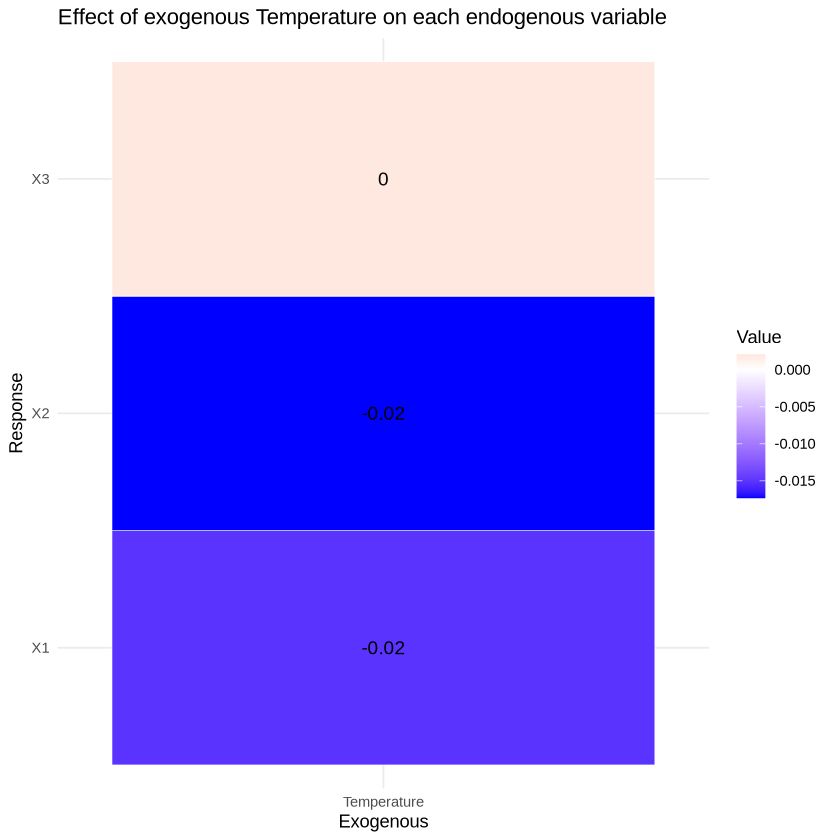

In [9]:
# Pull out the Temperature coefficient row from each equation
B <- matrix(0, nrow = k, ncol = 1,
            dimnames = list(var_names, "Temperature"))
for (eq_idx in seq_len(k)) {
    coef_eq <- coef(fit_varx)[[eq_idx]]
    if ("Temperature" %in% rownames(coef_eq)) {
        B[eq_idx, 1] <- coef_eq["Temperature", "Estimate"]
    }
}

df_exo <- melt(B)
colnames(df_exo) <- c("Response", "Exogenous", "Value")

ggplot(df_exo, aes(x = Exogenous, y = Response, fill = Value)) +
    geom_tile(color = "white") +
    geom_text(aes(label = round(Value, 2)), size = 4) +
    scale_fill_gradient2(low = "blue", mid = "white", high = "red") +
    theme_minimal() +
    labs(title = "Effect of exogenous Temperature on each endogenous variable")

### Discussion

- Which variables are best explained, which are hardest? Why?
- Does the exogenous variable affect all endogenous variables equally?
- What would you do if you suspected the "exogenous" assumption was wrong?
- How would you extend this to **multiple** exogenous variables?

---

## Wrap-up

- Reason about endogeneity vs exogeneity in your modelling decisions.
- Fit a VARX with `VAR(..., exogen = ...)`.
- Read off endogenous-lag and exogenous coefficient effects.

Next: **sparse VAR** for high-dimensional systems (Exercise 09).